In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [3]:
df = pd.read_csv("ipl2025.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           74 non-null     int64  
 1   index                74 non-null     int64  
 2   match_id             74 non-null     int64  
 3   date                 74 non-null     object 
 4   venue                74 non-null     object 
 5   team1                74 non-null     object 
 6   team2                74 non-null     object 
 7   stage                74 non-null     object 
 8   toss_winner          73 non-null     object 
 9   toss_decision        74 non-null     object 
 10  first_ings_score     73 non-null     float64
 11  first_ings_wkts      73 non-null     float64
 12  second_ings_score    72 non-null     float64
 13  second_ings_wkts     72 non-null     float64
 14  match_result         74 non-null     object 
 15  match_winner         71 non-null     objec

In [5]:
df.describe()

,Unnamed: 0,index,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,balls_left,highscore,match_no,total_runs_off_bat,total_extras,total_wides,total_noballs,total_wickets,win_by_runs,win_by_wickets
count,74.000000,74.000000,74.000000,73.000000,73.000000,72.000000,72.000000,72.000000,71.000000,74.000000,73.000000,73.000000,73.000000,73.000000,73.000000,71.000000,74.000000
mean,36.500000,36.500000,37.500000,189.753425,6.452055,174.013889,5.513889,10.819444,74.549296,37.500000,345.150685,16.095890,9.013699,0.931507,11.945205,15.535211,2.702703
std,21.505813,21.505813,21.505813,37.489547,2.108456,38.805217,2.882649,17.674942,20.088226,21.505813,69.194507,6.390454,4.257324,1.158648,3.201087,25.682029,3.957755
min,0.000000,0.000000,1.000000,95.000000,2.000000,7.000000,0.000000,0.000000,37.000000,1.000000,128.000000,3.000000,1.000000,0.000000,3.000000,0.000000,-1.000000
25%,18.250000,18.250000,19.250000,166.000000,5.000000,158.000000,3.000000,0.000000,61.000000,19.250000,312.000000,11.000000,6.000000,0.000000,11.000000,0.000000,-1.000000
50%,36.500000,36.500000,37.500000,196.000000,6.000000,177.000000,5.000000,5.500000,73.000000,37.500000,349.000000,16.000000,9.000000,1.000000,12.000000,0.000000,0.000000
75%,54.750000,54.750000,55.750000,213.000000,8.000000,201.250000,8.000000,13.500000,88.500000,55.750000,395.000000,21.000000,12.000000,2.000000,14.000000,19.000000,6.750000
max,73.000000,73.000000,74.000000,286.000000,10.000000,247.000000,10.000000,114.000000,141.000000,74.000000,497.000000,30.000000,23.000000,5.000000,20.000000,110.000000,10.000000


In [6]:
df.describe(include='O')

,date,venue,team1,team2,stage,toss_winner,toss_decision,match_result,match_winner,wb_runs,wb_wickets,player_of_the_match,top_scorer,best_bowling,best_bowling_figure
count,74,74,74,74,74,73,74,74,71,34,38,71,71,71,71
unique,62,13,10,10,3,10,2,2,10,28,11,53,41,42,54
top,"March 23,2025","Narendra Modi Stadium, Ahmedabad",PBKS,MI,League,PBKS,Bowl,completed,PBKS,12,8,Krunal Pandya,Virat Kohli,Prasidh Krishna,2--25
freq,2,9,9,9,70,12,61,71,11,3,9,3,4,5,4


In [7]:
# sns.set_style('darkgrid')
# matplotlib.rcParams['font.size'] = 14
# matplotlib.rcParams['figure.figsize'] = (10, 6)
# matplotlib.rcParams['figure.facecolor'] = '#00000000'

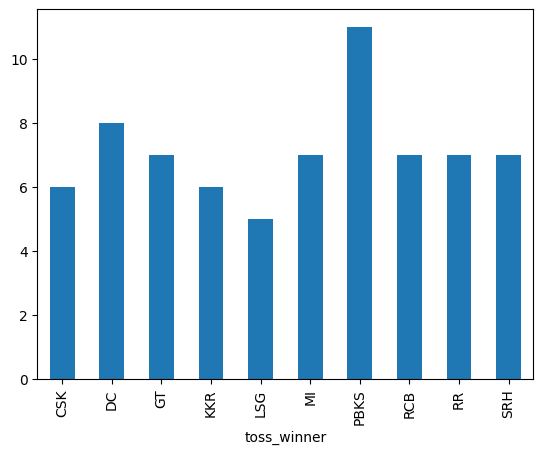

In [8]:
df.groupby('toss_winner')['match_winner'].count().plot.bar()
plt.show()

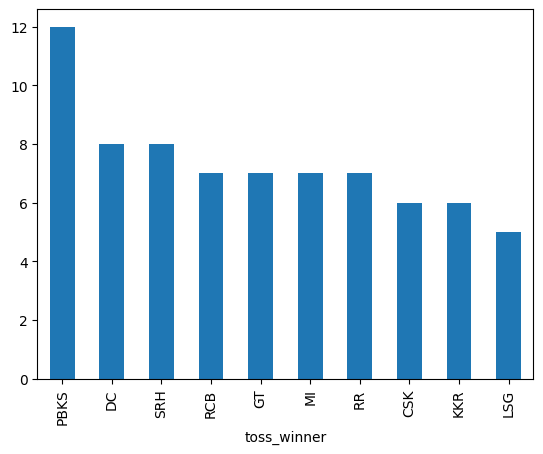

In [9]:
df.groupby('toss_winner')['toss_winner'].count().sort_values(ascending=False).plot.bar()
plt.show()

# Team that won the most toss


In [10]:
toss_winner = df.groupby("toss_winner").count().sort_values("match_id",ascending=False)
toss_winner.index.name = "teams"
toss_winner = toss_winner.rename(columns={'index': 'Toss_Won'})
toss_winner[["Toss_Won"]]
# There are total 73 Toss won

,Toss_Won
teams,
PBKS,12
DC,8
SRH,8
RCB,7
GT,7
MI,7
RR,7
CSK,6
KKR,6


In [11]:
df_toss_winner_match_winner = df[df["toss_winner"] == df["match_winner"]]
df_toss_winner_match_winner=df_toss_winner_match_winner.groupby("toss_winner").count().sort_values("match_id",ascending=False)
df_toss_winner_match_winner.reset_index()
df_toss_winner_match_winner.index.name = "Teams"
df_toss_winner_match_winner = df_toss_winner_match_winner.rename(columns={'index':'Toss_Won_Match_Won'})
df_toss_winner_match_winner[['Toss_Won_Match_Won']]
# There are total 42 matchs in which toss won and match won

,Toss_Won_Match_Won
Teams,
PBKS,8
DC,6
RCB,5
GT,5
MI,4
CSK,3
LSG,3
KKR,3
SRH,3


<Figure size 600x600 with 0 Axes>

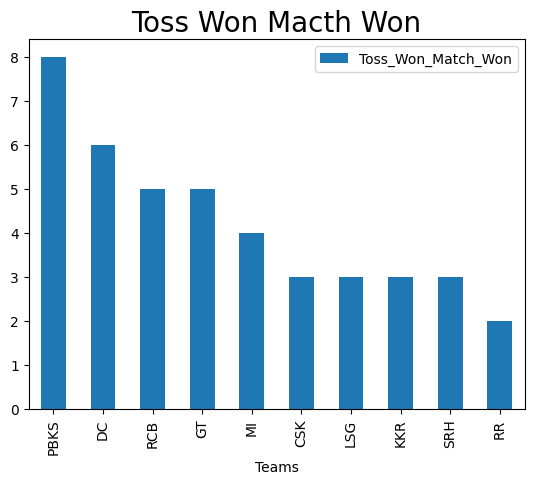

In [12]:
plt.figure(figsize=(6,6))
df_toss_winner_match_winner[["Toss_Won_Match_Won"]].plot.bar()
plt.title("Toss Won Macth Won", fontsize=20)
plt.show()

In [13]:
df_toss_winner_match_lost = df[df["toss_winner"] != df["match_winner"]]
df_toss_winner_match_lost=df_toss_winner_match_lost.groupby("toss_winner").count().sort_values("match_id",ascending=False)
# df_toss_winner[["match_winner"]]
df_toss_winner_match_lost.reset_index()
df_toss_winner_match_lost.index.name = "Teams"
df_toss_winner_match_lost = df_toss_winner_match_lost.rename(columns={'match_id':'Toss Win and Match Lost'})
df_toss_winner_match_lost[['Toss Win and Match Lost']]
# There are total 31 matchs in which toss won and match lost

,Toss Win and Match Lost
Teams,
SRH,5
RR,5
PBKS,4
CSK,3
MI,3
KKR,3
DC,2
GT,2
LSG,2


<Figure size 600x600 with 0 Axes>

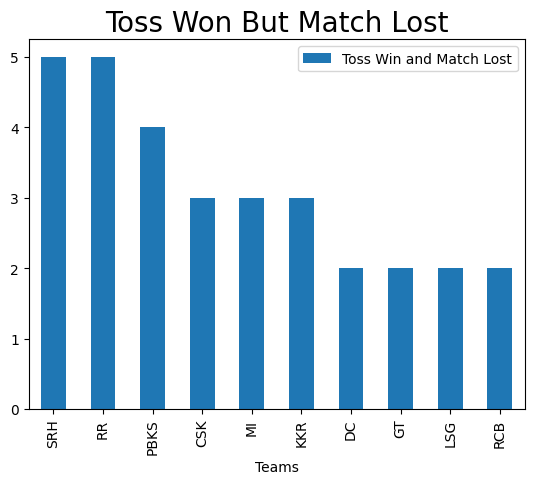

In [14]:
plt.figure(figsize=(6,6))
df_toss_winner_match_lost[["Toss Win and Match Lost"]].plot.bar()
plt.title("Toss Won But Match Lost", fontsize=20)
plt.show()

In [15]:
df_toss_lost_matach_winner = df[df["match_winner"] != df["toss_winner"]]
df_toss_lost_matach_winner=df_toss_lost_matach_winner.groupby("match_winner").count().sort_values("match_id",ascending=False)
df_toss_lost_matach_winner.reset_index()
df_toss_lost_matach_winner.index.name = "Teams"
df_toss_lost_matach_winner = df_toss_lost_matach_winner.rename(columns={'index':'Toss_Lost_But_Match_Won'})
df_toss_lost_matach_winner[["Toss_Lost_But_Match_Won"]]

,Toss_Lost_But_Match_Won
Teams,
RCB,5
GT,4
MI,4
PBKS,3
SRH,3
LSG,3
KKR,2
DC,2
RR,2


<Figure size 600x600 with 0 Axes>

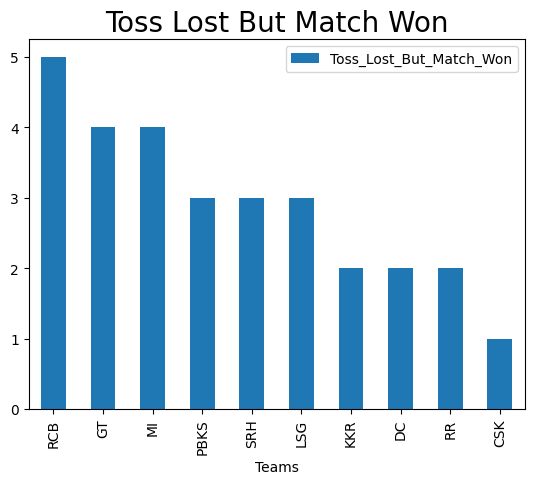

In [16]:
plt.figure(figsize=(6,6))
df_toss_lost_matach_winner[["Toss_Lost_But_Match_Won"]].plot.bar()
plt.title("Toss Lost But Match Won", fontsize=20)
plt.show()

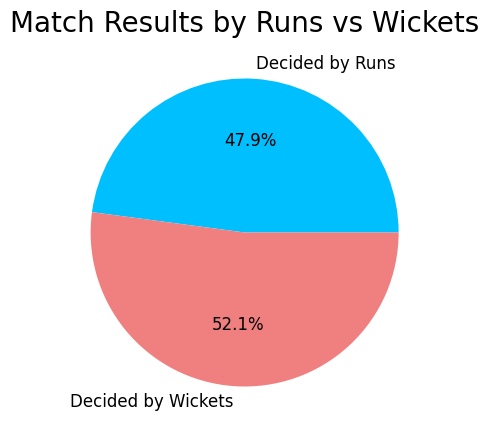

In [17]:
# win_by_runs = df['win_by_runs']
# win_by_wickets = df['win_by_wickets']
matches_by_runs = np.sum(df['win_by_runs'] > 0)
matches_by_wickets = np.sum(df['win_by_wickets'] > 0)

plt.figure(figsize=(5,5))
plt.pie([matches_by_runs, matches_by_wickets], labels=['Decided by Runs', 'Decided by Wickets'],autopct='%1.1f%%', colors=['deepskyblue', 'lightcoral'],textprops={'fontsize': 12})
plt.title('Match Results by Runs vs Wickets', fontsize = 20)
plt.show()


In [18]:
df_most_player_of_match = df.groupby("player_of_the_match").count()
df_most_player_of_match.reset_index()
df_most_player_of_match = df_most_player_of_match.rename(columns={'index':'Count'})
print(df_most_player_of_match.shape[0])
df_most_player_of_match[['Count']].sort_values("Count",ascending=False)

53


,Count
player_of_the_match,
Krunal Pandya,3
Shreyas Iyer,3
Ishan Kishan,2
Abhishek Sharma,2
KL Rahul,2
Prabhsimran Singh,2
Prasidh Krishna,2
Rohit Sharma,2
Rajat Patidar,2


In [19]:
df_most_top_scorer = df.groupby("top_scorer").count()
df_most_top_scorer.reset_index()
df_most_top_scorer = df_most_top_scorer.rename(columns={'index':'Count'})
print(f"Total Number of Top Scorer: {df_most_top_scorer.shape[0]}")
df_most_top_scorer[['Count']].sort_values("Count",ascending=False)

Total Number of Top Scorer: 41


,Count
top_scorer,
Nicholas Pooran,4
Virat Kohli,4
Yashasvi Jaiswal,3
KL Rahul,3
Sai Sudarshan,3
Shubman Gill,3
Ryan Rickelton,3
Ishan Kishan,3
Abhishek Sharma,2


In [20]:
df_most_best_bowling = df.groupby('best_bowling').count()
df_most_best_bowling = df_most_best_bowling.rename(columns={'index':'Times'})
df_most_best_bowling = df_most_best_bowling.sort_values("Times",ascending=False)
print(f"Total Plyers who have best bowling figures: {df_most_best_bowling.shape[0]}")
df_most_best_bowling[['Times']]

Total Plyers who have best bowling figures: 42


,Times
best_bowling,
Prasidh Krishna,5
Arshdeep Singh,4
Krunal Pandya,4
Josh Hazlewood,3
Jasprit Bumrah,3
Noor Ahmad,3
Varun Chakravarthy,3
Karn Sharma,2
Jaydev Unadkat,2


In [21]:
df_top_scorer_player_of_match = df[df['player_of_the_match'] == df['top_scorer']]
df_top_scorer_player_of_match['player_of_the_match']
df_top_scorer_player_of_match = df_top_scorer_player_of_match.groupby("top_scorer").count().sort_values('index',ascending=False)
print(df_top_scorer_player_of_match.shape[0])
df_top_scorer_player_of_match[['index']]

26


,index
top_scorer,
KL Rahul,2
Ishan Kishan,2
Shreyas Iyer,2
Sai Sudarshan,2
Rohit Sharma,2
Prabhsimran Singh,2
Dewald Brevis,1
Abhishek Sharma,1
Jos Buttler,1


In [22]:
df_best_bowl_player_of_match = df[df['player_of_the_match'] == df['best_bowling']]
df_best_bowl_player_of_match['player_of_the_match']
df_best_bowl_player_of_match = df_best_bowl_player_of_match.groupby("best_bowling").count().sort_values('index',ascending=False)
print(df_best_bowl_player_of_match.shape[0])
df_best_bowl_player_of_match[['index']]


19


,index
best_bowling,
Sunil Narine,2
Noor Ahmad,2
Mohammed Siraj,2
Avesh Khan,1
Ashwani Kumar,1
Akash Madhwal,1
Harpreet Brar,1
Josh Hazlewood,1
Karn Sharma,1


# Player of the match but not the top scorer or not has best bowling


In [23]:
df_player_of_the_match_not = df[(df['player_of_the_match'] != df['top_scorer']) & (df['player_of_the_match'] != df['best_bowling'])]
print(df_player_of_the_match_not.shape[0])
print(df_player_of_the_match_not[["best_bowling","top_scorer","player_of_the_match"]])


21
          best_bowling        top_scorer player_of_the_match
3       Mitchell Starc   Nicholas Pooran     Ashutosh Sharma
14  Varun Chakravarthy    Venkatesh Iyer       Vaibhav Arora
15       Hardik Pandya  Suryakumar Yadav       Digvesh Singh
19       Krunal Pandya       Virat Kohli       Rajat Patidar
25     Prasidh Krishna   Nicholas Pooran       Aiden Markram
27       Krunal Pandya  Yashasvi Jaiswal           Phil Salt
29        Ravi Bishnoi      Rishabh Pant            MS Dhoni
31        Jofra Archer       Nitish Rana      Mitchell Starc
32         Pat Cummins   Abhishek Sharma          Will Jacks
43                 NaN               NaN                 NaN
44      Jasprit Bumrah    Ryan Rickelton          Will Jacks
48    Yuzvendra Chahal        Sam Curran        Shreyas Iyer
50      Jaydev Unadkat      Shubman Gill     Prasidh Krishna
51         Lungi Ngidi      Ayush Mhatre    Romario Shepherd
52  Varun Chakravarthy       Riyan Parag       Andre Russell
54                 Na

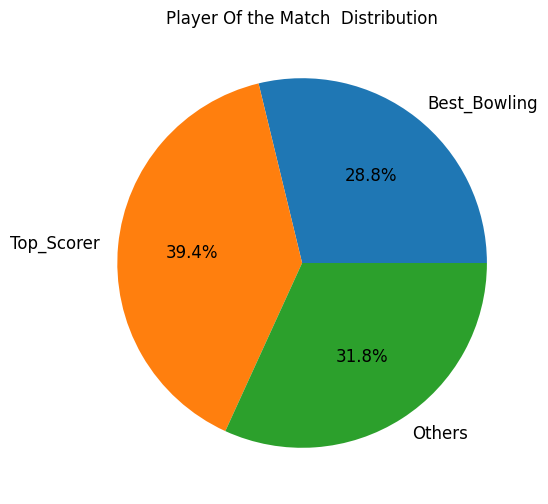

In [24]:
number_of_batsman = df_top_scorer_player_of_match.shape[0]
number_of_bolwer = df_best_bowl_player_of_match.shape[0]
number_of_others = df_player_of_the_match_not.shape[0]

plt.figure(figsize=(6,6))
plt.pie([number_of_bolwer,number_of_batsman,number_of_others],labels=["Best_Bowling","Top_Scorer","Others"],autopct='%1.1f%%',textprops={'fontsize': 12})
plt.title("Player Of the Match  Distribution")
plt.show()

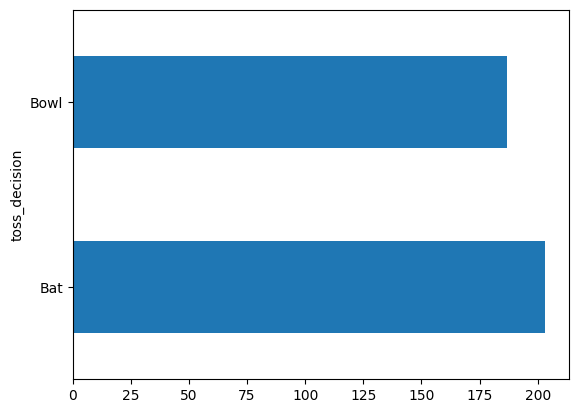

In [25]:
df.groupby('toss_decision')['first_ings_score'].mean().plot.barh()
plt.show()

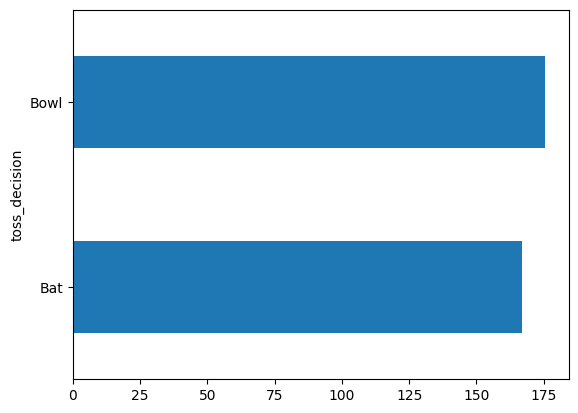

In [26]:
df.groupby('toss_decision')['second_ings_score'].mean().plot.barh()
plt.show()

In [27]:
df

,Unnamed: 0,index,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,...,best_bowling,best_bowling_figure,match_no,total_runs_off_bat,total_extras,total_wides,total_noballs,total_wickets,win_by_runs,win_by_wickets
0,0,0,1,"March 22,2025","Eden Gardens, Kolkata",KKR,RCB,League,RCB,Bowl,...,Krunal Pandya,3--29,1,342.0,9.0,5.0,0.0,11.0,0.0,7.0
1,1,1,2,"March 23,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,RR,League,RR,Bowl,...,Tushar Deshpande,3--44,2,497.0,30.0,16.0,5.0,12.0,44.0,-1.0
2,2,2,3,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Bowl,...,Noor Ahmad,4--18,3,298.0,15.0,7.0,1.0,15.0,0.0,4.0
3,3,3,4,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Bowl,...,Mitchell Starc,3--42,4,405.0,15.0,8.0,1.0,17.0,0.0,1.0
4,4,4,5,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,GT,Bowl,...,Sai Kishore,3--30,5,449.0,24.0,12.0,0.0,10.0,11.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,69,69,70,"May 27,2025","Ekana Cricket Stadium, Lucknow",LSG,RCB,League,RCB,Bowl,...,Will O'Rourke,2--74,70,437.0,20.0,10.0,2.0,7.0,0.0,6.0
70,70,70,71,"May 29,2025","New PCA Cricket Stadium, Mullanpur",PBKS,RCB,Playoffs,RCB,Bowl,...,Suyash Sharma,3--17,71,192.0,15.0,1.0,1.0,12.0,0.0,8.0
71,71,71,72,"May 30,2025","New PCA Cricket Stadium, Mullanpur",GT,MI,Playoffs,MI,Bat,...,Sai Kishore,2--42,72,419.0,16.0,7.0,0.0,11.0,20.0,-1.0
72,72,72,73,"June 1,2025","Narendra Modi Stadium, Ahmedabad",PBKS,MI,Playoffs,PBKS,Bowl,...,Azmatullah Omarzai,2--43,73,397.0,13.0,7.0,3.0,11.0,0.0,5.0


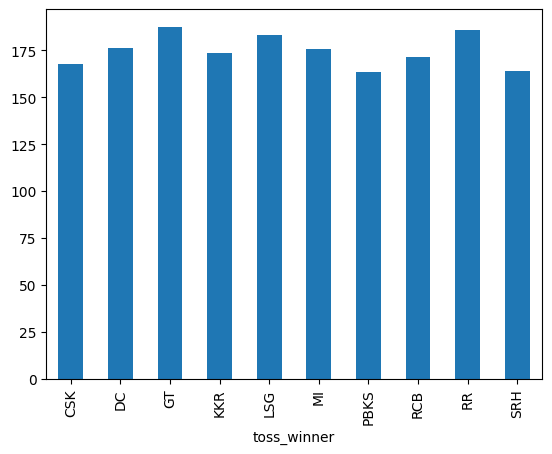

In [28]:
df.groupby('toss_winner')['second_ings_score'].mean().plot.bar()
plt.show()

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           74 non-null     int64  
 1   index                74 non-null     int64  
 2   match_id             74 non-null     int64  
 3   date                 74 non-null     object 
 4   venue                74 non-null     object 
 5   team1                74 non-null     object 
 6   team2                74 non-null     object 
 7   stage                74 non-null     object 
 8   toss_winner          73 non-null     object 
 9   toss_decision        74 non-null     object 
 10  first_ings_score     73 non-null     float64
 11  first_ings_wkts      73 non-null     float64
 12  second_ings_score    72 non-null     float64
 13  second_ings_wkts     72 non-null     float64
 14  match_result         74 non-null     object 
 15  match_winner         71 non-null     objec

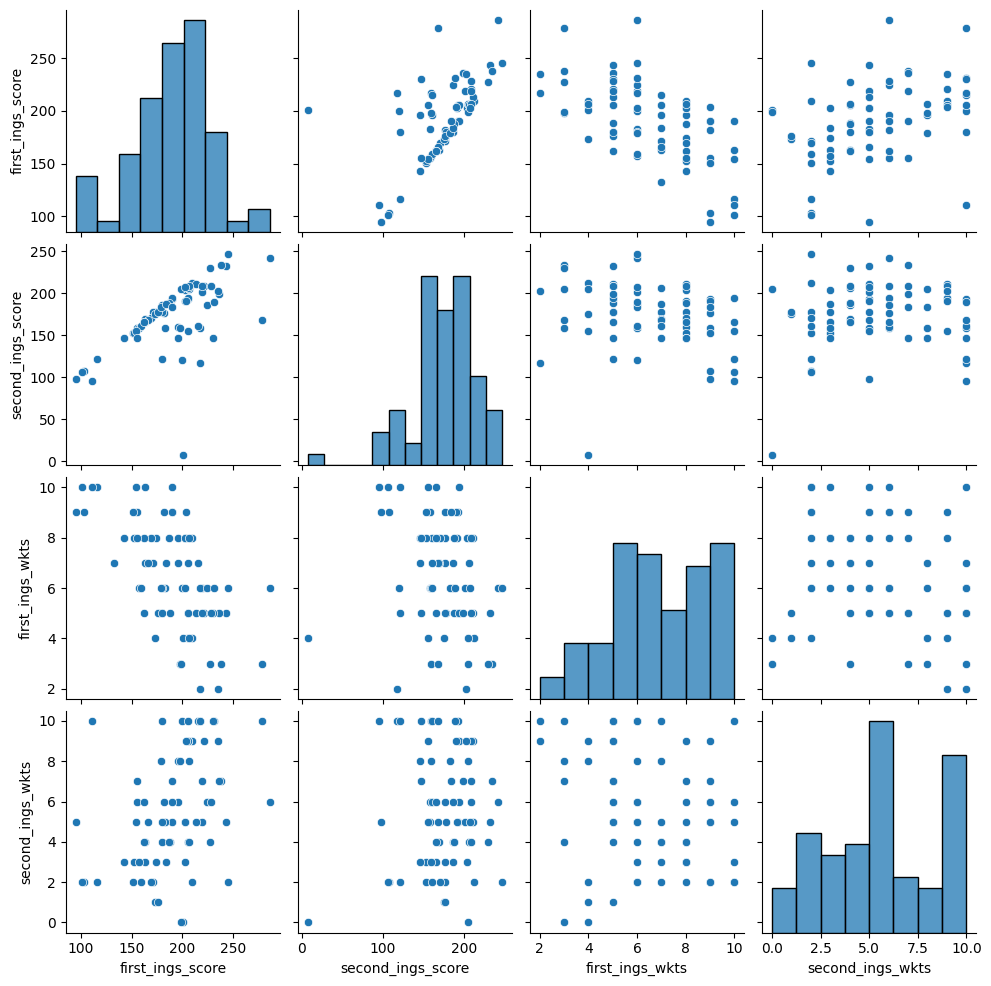

In [32]:
columns = ['first_ings_score','second_ings_score','first_ings_wkts','second_ings_wkts']
sns.pairplot(df[columns])